# QTT interleaved

# Comb Turbulence


## Create random comb

In [1]:
%cd ../..
import torch as tn
import torchtt as tntt
import numpy as np
from src.qtt_interpolation.comb import *


/home/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/nfs/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation


In [2]:
import secrets
def _seed64(seq: np.random.SeedSequence | None) -> int:
    if seq is None:
        return secrets.randbits(64)  # non-deterministic, independent
    # spawn a child, take 64 bits for torch.Generator
    child = seq.spawn(1)[0]
    return int(child.generate_state(1, dtype=np.uint64)[0])

def rand_comb(N, R, r, *, var=1.0, dtype=tn.float64, device=None, generator: tn.Generator | None = None):
    """
    Draws one set of random 'cores'. If `generator` is None, a fresh torch.Generator
    with a unique 64-bit seed is used (independent draw).
    """
    d = len(N)
    D = len(r) - 1

    v1 = (var / np.prod(R)) ** (1.0 / d)
    v2 = (var / np.prod(r)) ** (1.0 / D)

    g = generator
    if g is None:
        g = tn.Generator(device=device)
        g.manual_seed(_seed64(None))

    cores = []
    for j in range(D):
        branch  = [None] * (d + 1)
        # first core in the branch
        branch[0] = tn.randn((1, r[j] * r[j+1], R[0]), dtype=dtype, device=device, generator=g) * np.sqrt(v2)
        # remaining d cores
        for i in range(d):
            shape = (R[i], N[i][0], N[i][1], R[i+1]) if isinstance(N[i], tuple) else (R[i], N[i], R[i+1])
            branch[i+1] = tn.randn(shape, dtype=dtype, device=device, generator=g) * np.sqrt(v1)
        cores.append(branch)
    return cores

In [9]:
rd = 200
Rd = 40
p = 6
rc = rand_comb([2]*p,[rd]*p+[1],[1]+[Rd]*2+[1])
rc=tree_compress(rc,eps=1e-8)

In [10]:
comc= combqtt_full(rc)
[tntt.TT(c) for c in rc]

[TT with sizes and ranks:
 N = [40, 2, 2, 2, 2, 2, 2]
 R = [1, 40, 32, 16, 8, 4, 2, 1]
 
 Device: cpu, dtype: torch.float64
 #entries 5524 compression 2.1578125,
 TT with sizes and ranks:
 N = [1600, 2, 2, 2, 2, 2, 2]
 R = [1, 64, 32, 16, 8, 4, 2, 1]
 
 Device: cpu, dtype: torch.float64
 #entries 107860 compression 1.0533203125,
 TT with sizes and ranks:
 N = [40, 2, 2, 2, 2, 2, 2]
 R = [1, 40, 32, 16, 8, 4, 2, 1]
 
 Device: cpu, dtype: torch.float64
 #entries 5524 compression 2.1578125]

In [11]:
comc.mean(), comc.std(), comc.max(), comc.min(), comc.numel(), tn.sum(comc**2)**0.5

(tensor(0.0004, dtype=torch.float64),
 tensor(0.8945, dtype=torch.float64),
 tensor(6.8887, dtype=torch.float64),
 tensor(-5.9589, dtype=torch.float64),
 262144,
 tensor(457.9809, dtype=torch.float64))

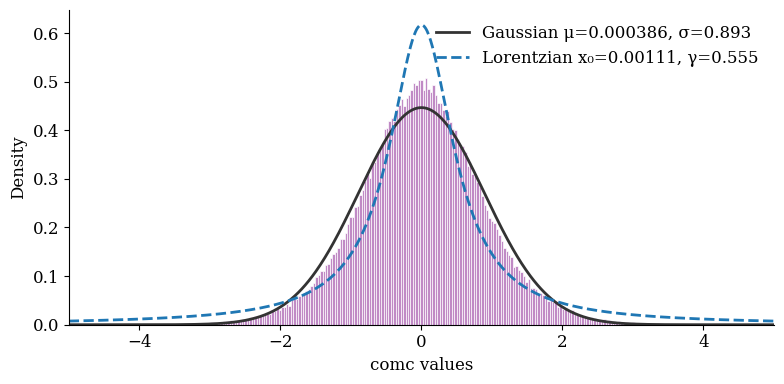

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import math

# ── Flatten to 1D NumPy and drop NaN/Inf ─────────────────────────────────────
def to_numpy(x):
    try:
        import torch
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
    except Exception:
        pass
    return np.asarray(x)

x = to_numpy(comc).ravel()
x = x[np.isfinite(x)]

# Window to [-5, 5]
lo, hi = -5.0, 5.0
xw = x[(x >= lo) & (x <= hi)]
if xw.size == 0:
    raise ValueError("No finite values within [-5, 5] to plot.")

# ── Fit parameters (no SciPy needed) ─────────────────────────────────────────
# Gaussian (use sample mean/std)
mu  = float(xw.mean())
sig = float(xw.std(ddof=0))
if sig <= 1e-12: sig = 1e-12

# Cauchy/Lorentzian via quartiles: q25=mu-gamma, q75=mu+gamma
q25, q75 = np.quantile(xw, [0.25, 0.75])
x0    = float(0.5*(q25 + q75))
gamma = float(0.5*(q75 - q25))
if gamma <= 1e-12: gamma = 1e-12

# PDFs and CDFs
def pdf_gauss(x, mu, sig):
    return (1.0/(sig*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sig)**2)

def cdf_gauss(x, mu, sig):
    return 0.5*(1.0 + math.erf((x-mu)/(sig*np.sqrt(2))))

def pdf_cauchy(x, x0, g):
    return (1.0/np.pi) * (g / ((x - x0)**2 + g**2))

def cdf_cauchy(x, x0, g):
    return 0.5 + (1.0/np.pi) * np.arctan((x - x0)/g)

# Window-normalize the PDFs so ∫_{lo}^{hi} pdf_win = 1 (to match histogram density)
Zg = cdf_gauss(hi, mu, sig) - cdf_gauss(lo, mu, sig)
Zc = cdf_cauchy(hi, x0, gamma) - cdf_cauchy(lo, x0, gamma)
Zg = max(Zg, 1e-12); Zc = max(Zc, 1e-12)

xx = np.linspace(lo, hi, 800)
pdfg_win = pdf_gauss(xx, mu, sig) / Zg
pdfc_win = pdf_cauchy(xx, x0, gamma) / Zc

# ── Figure (white bg) ────────────────────────────────────────────────────────
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

# Histogram as density over [-5,5]
hist_color = "#BD84C2"
ax.hist(xw, bins='auto', range=(lo, hi), density=True,
        color=hist_color, edgecolor='white', linewidth=0.5, alpha=0.95)

# Overlay fits
ax.plot(xx, pdfg_win, lw=2, label=f"Gaussian μ={mu:.3g}, σ={sig:.3g}", color="#333333")
ax.plot(xx, pdfc_win, lw=2, label=f"Lorentzian x₀={x0:.3g}, γ={gamma:.3g}", color="#1f77b4", ls='--')

ax.set_xlim(lo, hi)
ax.set_ylabel("Density")
ax.set_xlabel("comc values")
ax.legend(frameon=False)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


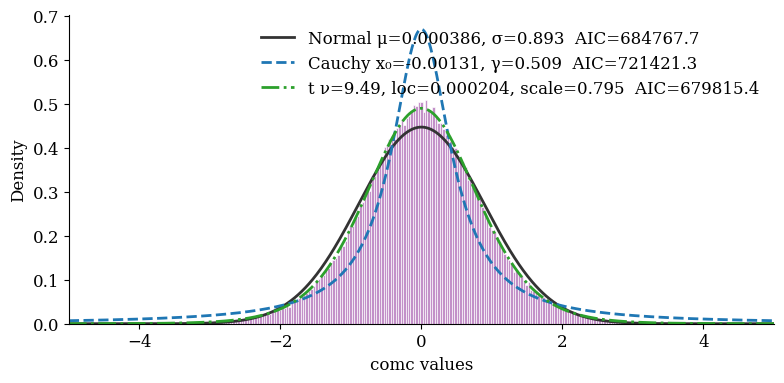

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# data window
lo, hi = -5.0, 5.0
x = np.asarray(comc).ravel()
x = x[np.isfinite(x)]
xw = x[(x >= lo) & (x <= hi)]
assert xw.size > 0

# MLE fits (untruncated params)
mu, sig = stats.norm.fit(xw)
x0, gam  = stats.cauchy.fit(xw)
nu, loc, scale = stats.t.fit(xw)  # Student-t

# window normalization constants Z = CDF(hi) - CDF(lo)
Zn = stats.norm.cdf(hi, mu, sig)    - stats.norm.cdf(lo, mu, sig)
Zc = stats.cauchy.cdf(hi, x0, gam)  - stats.cauchy.cdf(lo, x0, gam)
Zt = stats.t.cdf(hi, nu, loc, scale)- stats.t.cdf(lo, nu, loc, scale)

# truncated log-likelihoods (sum log f(x) - log Z)
ll_norm   = np.sum(stats.norm.logpdf(xw,   mu, sig))   - xw.size*np.log(Zn)
ll_cauchy = np.sum(stats.cauchy.logpdf(xw, x0, gam))   - xw.size*np.log(Zc)
ll_t      = np.sum(stats.t.logpdf(xw,      nu, loc, scale)) - xw.size*np.log(Zt)

# AIC = 2k - 2*LL  (k: #params)
AIC_norm, AIC_cauchy, AIC_t = 2*2 - 2*ll_norm, 2*2 - 2*ll_cauchy, 2*3 - 2*ll_t

# Plot
xx = np.linspace(lo, hi, 800)
pdf_norm   = stats.norm.pdf(xx,   mu, sig)    / Zn
pdf_cauchy = stats.cauchy.pdf(xx, x0, gam)    / Zc
pdf_t      = stats.t.pdf(xx,      nu, loc, scale) / Zt

fig, ax = plt.subplots(figsize=(8,4))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')
ax.hist(xw, bins='auto', range=(lo, hi), density=True,
        color="#BD84C2", edgecolor='white', linewidth=0.5, alpha=0.9)

ax.plot(xx, pdf_norm,   color="#333333", lw=2, label=f"Normal μ={mu:.3g}, σ={sig:.3g}  AIC={AIC_norm:.1f}")
ax.plot(xx, pdf_cauchy, color="#1f77b4", lw=2, ls='--', label=f"Cauchy x₀={x0:.3g}, γ={gam:.3g}  AIC={AIC_cauchy:.1f}")
ax.plot(xx, pdf_t,      color="#2ca02c", lw=2, ls='-.', label=f"t ν={nu:.2f}, loc={loc:.3g}, scale={scale:.3g}  AIC={AIC_t:.1f}")

ax.set_xlim(lo, hi); ax.set_ylabel("Density"); ax.set_xlabel("comc values")
ax.legend(frameon=False); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


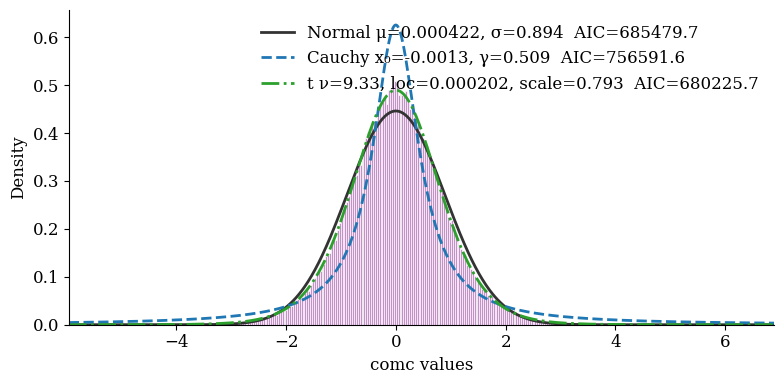

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── Flatten to 1D NumPy and drop NaN/Inf ─────────────────────────────────────
def to_numpy(x):
    try:
        import torch
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
    except Exception:
        pass
    return np.asarray(x)

x = to_numpy(comc).ravel()
x = x[np.isfinite(x)]
if x.size == 0:
    raise ValueError("No finite values to fit/plot.")

# ── MLE fits on FULL data (no window) ────────────────────────────────────────
mu,  sig        = stats.norm.fit(x)
x0,  gamma      = stats.cauchy.fit(x)
nu,  loc, scale = stats.t.fit(x)              # Student-t

# Full-data log-likelihoods and AIC
ll_norm   = np.sum(stats.norm.logpdf(x,   mu, sig))
ll_cauchy = np.sum(stats.cauchy.logpdf(x, x0, gamma))
ll_t      = np.sum(stats.t.logpdf(x,      nu, loc, scale))

AIC_norm   = 2*2 - 2*ll_norm     # k=2
AIC_cauchy = 2*2 - 2*ll_cauchy   # k=2
AIC_t      = 2*3 - 2*ll_t        # k=3

# ── Plot (white bg) ─────────────────────────────────────────────────────────
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

# Histogram over full range (density=True)
hist_color = "#BD84C2"
ax.hist(x, bins='fd', density=True,
        color=hist_color, edgecolor='white', linewidth=0.5, alpha=0.9)

# Overlay PDFs (no window normalization)
xx = np.linspace(x.min(), x.max(), 1000)
ax.plot(xx, stats.norm.pdf(xx,   mu, sig),        color="#333333", lw=2,
        label=f"Normal μ={mu:.3g}, σ={sig:.3g}  AIC={AIC_norm:.1f}")
ax.plot(xx, stats.cauchy.pdf(xx, x0, gamma),      color="#1f77b4", lw=2, ls='--',
        label=f"Cauchy x₀={x0:.3g}, γ={gamma:.3g}  AIC={AIC_cauchy:.1f}")
ax.plot(xx, stats.t.pdf(xx,      nu, loc, scale), color="#2ca02c", lw=2, ls='-.',
        label=f"t ν={nu:.2f}, loc={loc:.3g}, scale={scale:.3g}  AIC={AIC_t:.1f}")

ax.set_xlim(x.min(), x.max())
ax.set_ylabel("Density"); ax.set_xlabel("comc values")
ax.legend(frameon=False)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

# If extreme outliers make the plot unreadable, you can just ZOOM the view:
# qlo, qhi = np.quantile(x, [0.001, 0.999])
# ax.set_xlim(qlo, qhi)


## 3D Additive cascade

In [16]:

def gen_noisy_combs(Nscales,nrank,rrank=None,cscale=2,var=1,dims=3,pdim=2):
    if rrank is None:
        rrank = nrank
    noises = []
    for scale in range(cscale,Nscales):
        rcomb = rand_comb([pdim]*scale,[nrank]*scale+[1],[1]+[rrank]*(dims-1)+[1],var=var) 
        rcomb = tree_compress(rcomb,eps=1e-10)
        noises.append(rcomb)
    return noises

def comb_mul(a,comb):
    comb[0][0] = a*comb[0][0]
    return comb

def gen_comb_cascade_3d(Nscales=10, nrank=10, rrank=20,levels=None, seed=None,epsilon=0.1 , method = 'cubic', eps=1e-10,var=1,order=1, field='stream'):

    if levels is None:
        levels = Nscales
    if seed is not None:
        tn.manual_seed(seed)

    # Initialize the stream function uniformly.
    noisex = gen_noisy_combs(levels,nrank,rrank=rrank,var=var,cscale=2,dims=3,pdim=2)
    noisey = gen_noisy_combs(levels,nrank,rrank=rrank,var=var,cscale=2,dims=3,pdim=2)
    noisez = gen_noisy_combs(levels,nrank,rrank=rrank,var=var,cscale=2,dims=3,pdim=2)

    if field == 'stream':
        base_scaling = 2.0 ** (-4.0 / 3.0)
        for i in range(2,levels):
            scale = i 
            j = i - 2
            am = (base_scaling**scale) * epsilon 
            # Interpolate to full resolution using linear interpolation.
            if method =='linear':
                raise Exception('Not implemented')

            # Interpolate to full resolution using cuadratic interpolation.
            elif method == 'cuadratic':
                raise Exception('Not implemented')

            # Interpolate to full resolution using splines interpolation

            elif method == 'cubic':
                print(am)
                smooth_mpsx =  comb_mul(am, comb_interpolate_p(noisex[j],Nscales, eps=eps, order=order) )
                smooth_mpsy = comb_mul(am, comb_interpolate_p(noisey[j],Nscales, eps=eps, order=order) )
                smooth_mpsz = comb_mul(am, comb_interpolate_p(noisez[j],Nscales, eps=eps, order=order) )

            elif method == 'quadratic':
                smooth_mpsx = comb_mul(am, comb_interpolate_p_quad(noisex[j],Nscales, eps=eps))
                smooth_mpsy = comb_mul(am, comb_interpolate_p_quad(noisey[j],Nscales, eps=eps))
                smooth_mpsz = comb_mul(am, comb_interpolate_p_quad(noisez[j],Nscales, eps=eps))

            if i==2:
                Ax = smooth_mpsx
                Ay = smooth_mpsy
                Az = smooth_mpsz
            else:
                Ax = comb_sum(Ax,smooth_mpsx)
                Ax = tree_compress(Ax,eps=eps)
                Ay = comb_sum(Ay,smooth_mpsy)
                Ay = tree_compress(Ay,eps=eps)
                Az = comb_sum(Az,smooth_mpsz)
                Az = tree_compress(Az,eps=eps)

        return Az, Ay, Az

    elif field == 'velocity':
        base_scaling = 2.0 ** (-1.0/3.0)
        #pyAx = 0
        #pzAx = 0
        #pxAy = 0
        #pzAy = 0
        #pxAz = 0
        #pyAz = 0

        for i in range(2,levels):
            scale = i
            j = i - 2
            am = (base_scaling ** scale) * epsilon
            # Interpolate to full resolution using linear interpolation.
            if method ==    'linear':
                raise Exception('Not implemented')

            # Interpolate to full resolution using cuadratic interpolation.
            elif method == 'cuadratic':
                raise Exception('Not implemented')

            # Interpolate to full resolution using splines interpolation

            elif method == 'cubic':
                pyAx = comb_mul(am, comb_interpolate_p(noisex[j],Nscales, eps=eps, order=order,p_derivative=[0,1,0]) )
                pzAx =  comb_mul(am, comb_interpolate_p(noisex[j],Nscales, eps=eps, order=order,p_derivative=[0,0,1]) )

                pxAy =  comb_mul(am, comb_interpolate_p(noisey[j],Nscales, eps=eps, order=order,p_derivative=[1,0,0]) )
                pzAy =  comb_mul(am, comb_interpolate_p(noisey[j],Nscales, eps=eps, order=order,p_derivative=[0,0,1]) )

                pxAz =  comb_mul(am, comb_interpolate_p(noisez[j],Nscales, eps=eps, order=order,p_derivative=[1,0,0]) )
                pyAz =  comb_mul(am, comb_interpolate_p(noisez[j],Nscales, eps=eps, order=order,p_derivative=[0,1,0]) )
            elif method == 'quadratic':
                pyAx =   comb_mul(am, comb_interpolate_p_quad(noisex[j],Nscales, eps=eps,p_derivative=[0,1,0]) )
                pzAx =   comb_mul(am, comb_interpolate_p_quad(noisex[j],Nscales, eps=eps,p_derivative=[0,0,1]) )

                pxAy =  comb_mul(am, comb_interpolate_p_quad(noisey[j],Nscales, eps=eps,p_derivative=[1,0,0]) )
                pzAy =  comb_mul(am, comb_interpolate_p_quad(noisey[j],Nscales, eps=eps,p_derivative=[0,0,1]) )

                pxAz =  comb_mul(am, comb_interpolate_p_quad(noisez[j],Nscales, eps=eps,p_derivative=[1,0,0]) )
                pyAz =  comb_mul(am, comb_interpolate_p_quad(noisez[j],Nscales, eps=eps,p_derivative=[0,1,0]) )
            print(comb_max_rank(pyAz), comb_max_rank(pzAy), comb_max_rank(pxAz), comb_max_rank(pyAx), comb_max_rank(pzAx), comb_max_rank(pxAy) )
            if i==2:
                vx = comb_sum(pyAz, comb_mul(-1,pzAy))
                vy = comb_sum(pzAx, comb_mul(-1,pxAz))
                vz = comb_sum(pxAy, comb_mul(-1,pyAx))
            else:
                vx = comb_sum(vx, comb_sum(pyAz, comb_mul(-1,pzAy)))
                vx = tree_compress(vx,eps=eps)
                
                vy = comb_sum(vy, comb_sum(pzAx, comb_mul(-1,pxAz)))
                vy = tree_compress(vy,eps=eps)

                vz = comb_sum(vz, comb_sum(pxAy, comb_mul(-1,pyAx)))
                vz = tree_compress(vz,eps=eps)

        #vy = tree_compress(vy,eps=eps)
        #vx = tree_compress(vx,eps=eps)
        #vz = tree_compress(vz,eps=eps)

        return vx, vy, vz
    else:
        raise Exception('Field not implemented')
@nb.njit(parallel=True)
def compute_velocity_from_vector_potential_p(Ax, Ay, Az, L=2*np.pi):
    N = Ax.shape[0]
    inv2dx = N / (2.0 * L)  # = 1/(2*dx)
    u = np.empty_like(Ax)
    v = np.empty_like(Ax)
    w = np.empty_like(Ax)

    for i in nb.prange(N):
        ip = (i + 1) % N
        im = (i - 1) % N
        for j in range(N):
            jp = (j + 1) % N
            jm = (j - 1) % N
            for k in range(N):
                kp = (k + 1) % N
                km = (k - 1) % N

                u[i, j, k] = ((Az[i, jp, k] - Az[i, jm, k])
                             - (Ay[i, j, kp] - Ay[i, j, km])) * inv2dx

                v[i, j, k] = ((Ax[i, j, kp] - Ax[i, j, km])
                             - (Az[ip, j, k] - Az[im, j, k])) * inv2dx

                w[i, j, k] = ((Ay[ip, j, k] - Ay[im, j, k])
                             - (Ax[i, jp, k] - Ax[i, jm, k])) * inv2dx

    return u,v,w



In [ ]:
from metrics.turbulence.cascade import *
import pandas as pd
from time import time
# %% Configuration
nscales  = 10
N        = 2**nscales
L        =  2 * np.pi
nrank    = 100
rrank = 10
epsilon  = 1.0
var      = 1
eps      = 1e-10
max_sep  = N//2
num_runs = 1
initial = 0


# %% Precompute radial bins
kx = 2 * np.pi * np.fft.fftfreq(N, d=L/N)
ky = kx
kz = 2 * np.pi * np.fft.rfftfreq(N, d=L/N)
KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
KX_shifted = np.fft.fftshift(KX)
KY_shifted = np.fft.fftshift(KY)
KZ_shifted = np.fft.fftshift(KZ)
k_mag = np.sqrt(KX_shifted**2 + KY_shifted**2 + KZ_shifted**2)

k_min     = 1.0
k_max     = k_mag.max() / np.sqrt(3)
num_bins  = N // 2
k_bins    = np.linspace(k_min, k_max, num_bins + 1)
k_centers = 0.5 * (k_bins[:-1] + k_bins[1:])
k_magnitude_flat = k_mag.ravel()

# Define bins in k (spherical shells)

k_min = k_magnitude_flat[k_magnitude_flat > 0].min()  # exclude zero to avoid log(0)
k_max = k_magnitude_flat.max()/1.7
bins = np.linspace(0.0, k_max, num_bins+1)  # num_bins bins
bin_centers = 0.5 * (bins[:-1] + bins[1:])
delta_k = bins[1:] - bins[:-1]

# %% Main loop
flat_records   = []
energy_records = []

for run_idx in range(initial,initial+num_runs):
    print("run", run_idx,flush=True)
    t = time()
    Ax, Ay, Az = gen_comb_cascade_3d(
        Nscales=nscales, nrank=nrank,rrank=rrank, levels=None, seed=None,
        epsilon=epsilon, method='cubic', order=1,
        eps=eps, var=var,field='velocity'
    )
    print(time()-t)
    print('cascade done')
    #tntt.save(Ax, f'./data/mps/vel/8_qtt_8/vx_run{run_idx}.TT')
    #tntt.save(Ay, f'./data/mps/vel/8_qtt_8/vy_run{run_idx}.TT')
    #tntt.save(Az, f'./data/mps/vel/8_qtt_8/vz_run{run_idx}.TT')

    
    A_x = combqtt_full(Ax)
    A_y = combqtt_full(Ay)
    A_z = combqtt_full(Az)
    print( comb_max_rank(Ax), comb_max_rank(Ay), comb_max_rank(Az) )
    
    #u, v, w = compute_velocity_from_vector_potential_p(A_x.numpy(), A_y.numpy(), A_z.numpy(), L)
    #u, v, w = tn.from_numpy(u), tn.from_numpy(v), tn.from_numpy(w)
    u, v, w = A_x, A_y, A_z

    u_hat = np.fft.rfftn(u)
    v_hat = np.fft.rfftn(v)
    w_hat = np.fft.rfftn(w)
    E_hat = (np.abs(u_hat)**2 + np.abs(v_hat)**2 + np.abs(w_hat)**2) / (N**6) /2
    E_hat_shifted = np.fft.fftshift(E_hat)

    E_flat = E_hat.ravel()
    
    # 3. Get wavenumbers in 3D.
    e_flat = E_hat_shifted.flatten()


    # Bin the energy using np.histogram with weights:
    bin_energy, _ = np.histogram(k_magnitude_flat, bins=bins, weights=e_flat)
    # Normalize by the bin width to obtain an estimate of the energy density E(k)
    E_k = bin_energy / delta_k

    nonzero = (E_k > 0)  & (bin_centers > 0)

    for kc, Ek in zip(k_centers[nonzero], E_k[nonzero]):
        energy_records.append({
            'run_idx': run_idx,
            'k_center': kc,
            'E_k': Ek
        })

    seps, flats = compute_flatness_p(u.numpy(), max_sep, L)
    for sep, flat in zip(seps, flats):
        flat_records.append({
            'run_idx': run_idx,
            'separation': sep,
            'flatness': flat
        })

df_flatness = pd.DataFrame(flat_records)
df_energy = pd.DataFrame(energy_records)

In [37]:
nscales = 10
epsilon  = 1.0
var      = 1
eps      = 1e-12
nrank    = 20
rrank = 250
Ax, Ay, Az = gen_comb_cascade_3d(
        Nscales=nscales, nrank=nrank,rrank=rrank, levels=None, seed=None,
        epsilon=epsilon, method='cubic', order=2,
        eps=eps, var=var,field='velocity'
    )
print(comb_max_rank(Ax), comb_max_rank(Ay), comb_max_rank(Az))
u,v,w = combqtt_full(Ax), combqtt_full(Ay), combqtt_full(Az)

4 4 4 4 4 4
8 8 8 8 8 8
16 16 16 16 16 16
20 20 20 20 20 20
23 23 23 23 23 23
23 23 23 23 23 23
23 23 23 23 23 23
23 23 23 23 23 23
223 223 223


In [41]:
(1/2**12)**4

3.552713678800501e-15

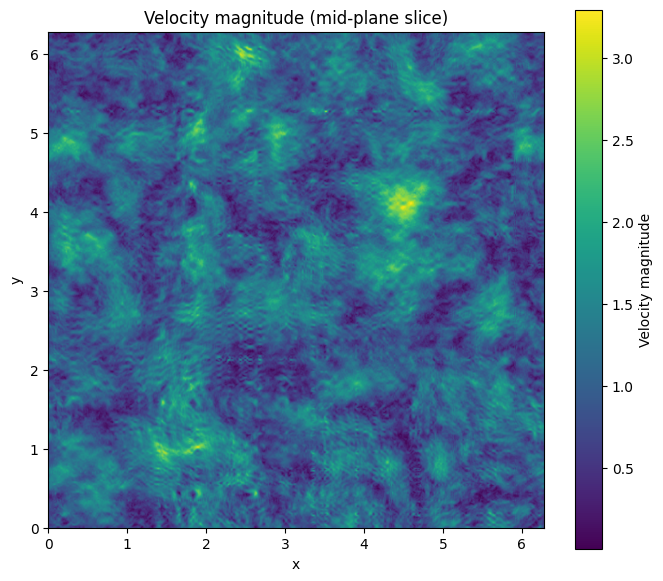

In [38]:
mw = tn.sqrt(u**2 + v**2 + w**2)
mw = mw / tn.mean(mw) 
# Plot velocity magnitude for Fourier-generated field (mid-plane slice)
plt.figure(figsize=(8, 7))
plt.imshow(mw[:,:,500], origin="lower", extent=[0, 2 * np.pi, 0, 2 * np.pi], cmap="viridis")
plt.colorbar(label="Velocity magnitude")
plt.title("Velocity magnitude (mid-plane slice)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

-1.6451860250707808


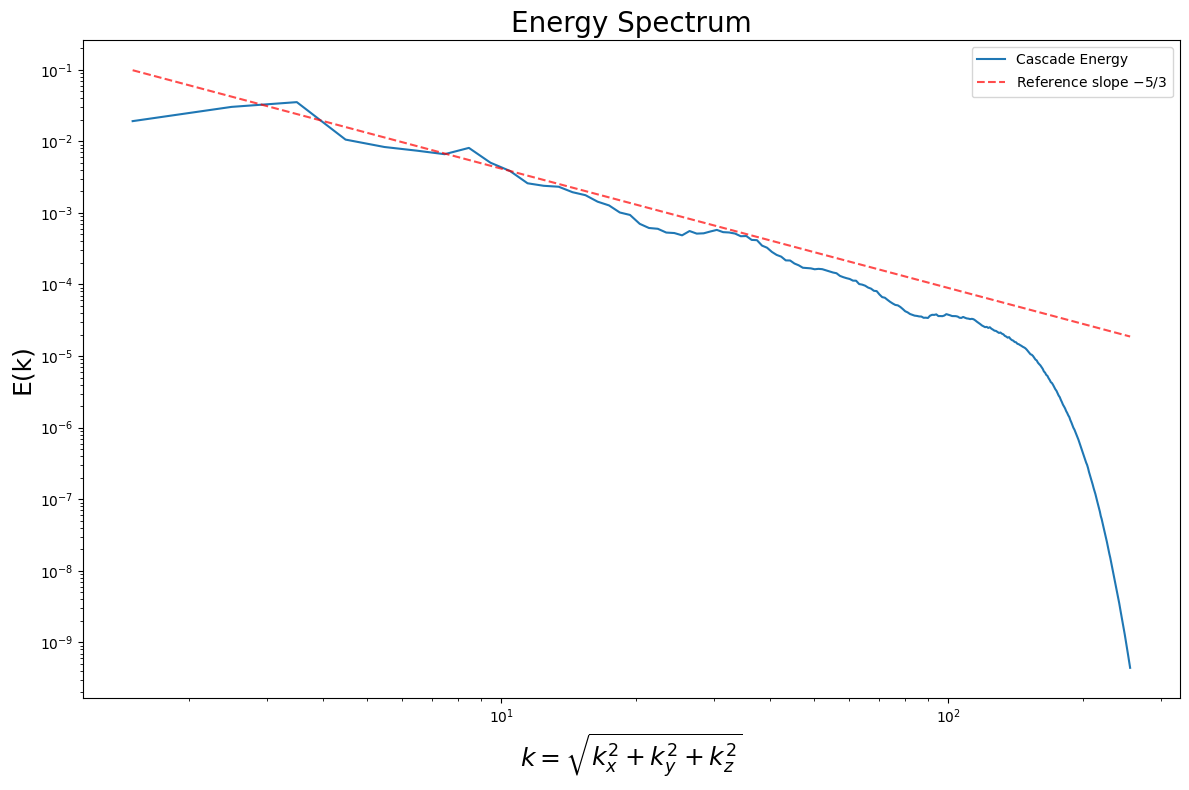

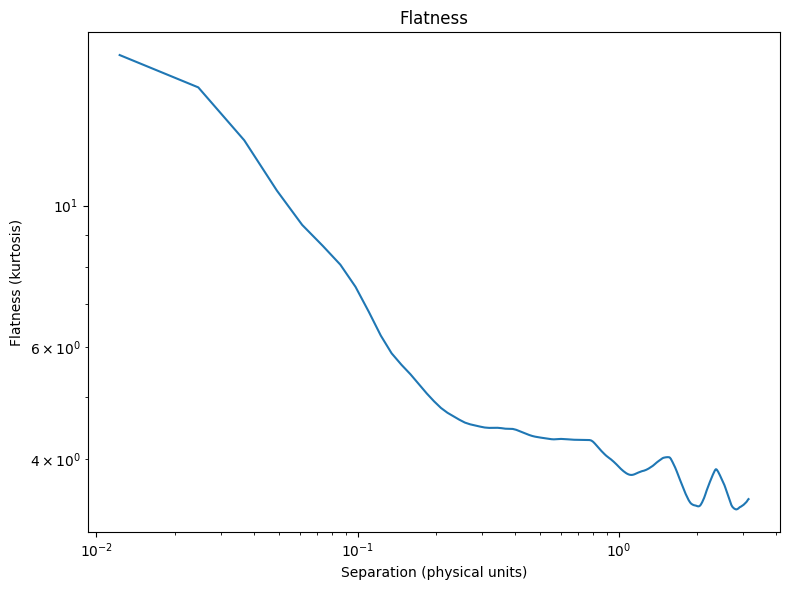

In [8]:


# 1) Energy statistics: mean and std over runs at each k_center
energy_stats = df_energy.groupby('k_center')['E_k'].agg(['mean', 'std']).reset_index()
k      = energy_stats['k_center'].values
E_mean = energy_stats['mean'].values
E_std  = energy_stats['std'].values

# --- Reference line with slope -5/3 ---
k_ref = np.linspace(k.min(), k.max(), 200)
ref_slope = -5/3
# Choose reference level so that it matches roughly the curve height
ref_intercept = np.log(E_mean[ (k > 10) & (k < 400) ][0]) - ref_slope * np.log(k[(k > 10) & (k < 400)][0])
print(ref_intercept)
ref_line = np.exp(ref_intercept) * k_ref**(ref_slope)

# --- Plot ---
plt.figure(figsize=(12, 8))
plt.loglog(k, E_mean, label='Cascade Energy', color='tab:blue')
plt.fill_between(k, E_mean - E_std, E_mean + E_std, alpha=0.3, color='tab:blue')
# plt.loglog(k, fit_line, '--', color='red', alpha=0.5, label=f"Fit: slope = {slope:.2f}")
plt.loglog(k_ref, ref_line, '--', color='red', alpha=0.7, label=r"Reference slope $-5/3$")

plt.xlabel(r"$k = \sqrt{k_x^2 + k_y^2 + k_z^2}$", fontsize=18)
plt.ylabel("E(k)",fontsize=18)
plt.title("Energy Spectrum",fontsize=20)
plt.legend()
plt.tight_layout()
plt.show()

flat_stats = df_flatness.groupby('separation')['flatness'].agg(['mean', 'std']).reset_index()
s       = flat_stats['separation'].values
F_mean  = flat_stats['mean'].values
F_std   = flat_stats['std'].values

# Plot flatness vs separation in log-log space
plt.figure(figsize=(8, 6))
plt.loglog(s, F_mean, label='Cascade Flatness')
plt.fill_between(s, F_mean - F_std, F_mean + F_std, alpha=0.3)
plt.xlabel("Separation (physical units)")
plt.ylabel("Flatness (kurtosis)")
plt.title("Flatness")
#plt.legend()
plt.tight_layout()
plt.show()

In [35]:

import math
def show_slices(data, axes=(0, 1, 2), cmap='viridis'):
    """
    Display all 2D slices of a 3D array along the specified axes in a square layout.

    Parameters
    ----------
    data : np.ndarray or torch.Tensor
        A 3D array, shape (D0, D1, D2).
    axes : sequence of int
        Which axes to slice over. Each must be 0, 1, or 2.
    cmap : str
        Matplotlib colormap to use.
    """
    assert data.ndim == 3, "input must be 3D"

    for axis in axes:
        n = data.shape[axis]
        cols = math.ceil(np.sqrt(n))
        rows = math.ceil(n / cols)

        fig, axs = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
        axs = np.array(axs).reshape(-1)  # flatten in case axs is 2D

        for i in range(rows * cols):
            ax = axs[i]
            if i < n:
                slicer = [slice(None)] * 3
                slicer[axis] = i
                slice_2d = data[tuple(slicer)]

                ax.imshow(slice_2d.T, cmap=cmap, origin='lower')
                ax.set_title(f'axis {axis} slice {i}')
            ax.axis('off')

        plt.tight_layout()
        plt.show()